# Predicting Profit: Machine Learning for Financial Analytics

This notebook builds and interprets machine learning models to predict profit and understand the key drivers of profitability in a financial dataset. The focus is on actionable business insights and model interpretability.

## 1. Load Cleaned Dataset

In [ ]:
import pandas as pd
import numpy as np

# Load the cleaned dataset
data_path = "../data/processed/financial_data_clean.csv"
df = pd.read_csv(data_path, sep=";", decimal=",")
df.head()

,date,revenue,cost,units_sold,profit,margin,revenue_per_unit,year,month,region_East,region_North,region_South,region_West,product_Product A,product_Product B,product_Product C,product_Product D
0,2022-01-01,11676.28,8294.08,252,3382.20,0.29,46.33,2022,1,False,True,False,False,True,False,False,False
1,2022-01-01,19338.47,10875.20,420,8463.27,0.44,46.04,2022,1,False,True,False,False,False,True,False,False
2,2022-01-01,15357.31,7417.66,338,7939.65,0.52,45.44,2022,1,False,True,False,False,False,False,True,False
3,2022-01-01,11775.49,10130.02,271,1645.47,0.14,43.45,2022,1,False,True,False,False,False,False,False,True
4,2022-01-01,19121.76,14368.00,480,4753.76,0.25,39.84,2022,1,False,False,True,False,True,False,False,False


## 2. Define Features and Target

In [73]:
# Target variable
y = df['profit']
# Drop columns not used as features
X = df.drop(['profit', 'date','year','margin','revenue'], axis=1)
X.head()

,cost,units_sold,revenue_per_unit,month,region_East,region_North,region_South,region_West,product_Product A,product_Product B,product_Product C,product_Product D
0,8294.08,252,46.33,1,False,True,False,False,True,False,False,False
1,10875.20,420,46.04,1,False,True,False,False,False,True,False,False
2,7417.66,338,45.44,1,False,True,False,False,False,False,True,False
3,10130.02,271,43.45,1,False,True,False,False,False,False,False,True
4,14368.00,480,39.84,1,False,False,True,False,True,False,False,False


## 3. Train-Test Split

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (460, 12), Test shape: (116, 12)


## 4. Linear Regression Model

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Evaluation
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(f'Linear Regression R2: {r2_lr:.3f}')
print(f'Linear Regression MAE: {mae_lr:.2f}')

Linear Regression R2: 0.984
Linear Regression MAE: 259.45


## 5. Linear Regression Coefficients and Interpretation

In [76]:
# Display coefficients with feature names
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
display(coef_df)

,Feature,Coefficient
2,revenue_per_unit,320.143656
1,units_sold,43.784619
10,product_Product C,-39.493954
6,region_South,-26.850979
8,product_Product A,21.626179
7,region_West,20.802281
9,product_Product B,9.821208
11,product_Product D,8.046567
5,region_North,7.866949
3,month,2.115729


## 6. Random Forest Regressor

In [77]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f'Random Forest R2: {r2_rf:.3f}')
print(f'Random Forest MAE: {mae_rf:.2f}')

Random Forest R2: 0.985
Random Forest MAE: 261.93


## 7. Model Comparison

In [78]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2': [r2_lr, r2_rf],
    'MAE': [mae_lr, mae_rf]
})
display(results)

,Model,R2,MAE
0,Linear Regression,0.984303,259.452420
1,Random Forest,0.984922,261.928402


## 8. Feature Importance (Random Forest)

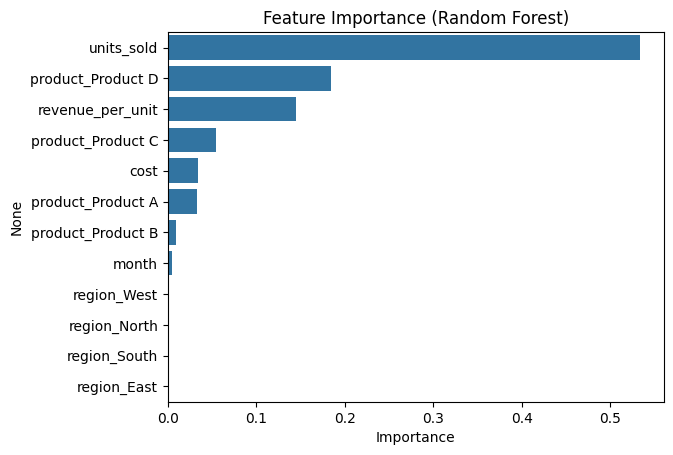

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

## 9. Business Insights and Interpretation

- **Key drivers of profitability**: The most important features identified by the models highlight which factors most influence profit.
- **Model comparison**: Comparing R2 and MAE helps select the best model for business use.
- **Interpretability**: Linear regression coefficients and random forest feature importances provide actionable insights for decision-makers.

